In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn transformers datasets torch

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ------------------- -------------------- 5.0/10.5 MB 27.4 MB/s eta 0:00:01
   ---------------------------------------  10.2/10.5 MB 29.0 MB/s eta 0:00:01
   ---------------------------------------- 10.5/10.5 MB 21.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 529.0/529.0 kB 8.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/660.6 kB ? eta -:--:--
   --------------------------------------- 660.6/660.6 kB 12.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/27.4 MB ? eta -:--:--
   ----- ---------------------------------- 3.7/27.4 MB 18.2 MB/s eta 0:00:02
   ------------- -------------------------- 9.2/27.4 MB 22.8 MB/s eta 0:00:01
   -------------------- ------------------- 14.2/27.4 MB 22.2 MB/s eta 0:00:01
   ----------------------------- ---------- 19.9/27.4 MB 23.3 MB/s eta 0:00:01
   -----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [5]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [7]:
df.columns

Index(['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat',
       'insult', 'identity_hate'],
      dtype='object')

In [9]:
df['toxic_label'] = df[['toxic','severe_toxic','obscene','threat','insult','identity_hate']].max(axis=1)

In [11]:
df = df.sample(8000, random_state=42)

In [13]:
df = df[['comment_text', 'toxic_label']]
df.columns = ['text', 'label']

In [15]:
df['label'].value_counts()

label
0    7201
1     799
Name: count, dtype: int64

### MODEL

In [18]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96      1437
           1       1.00      0.26      0.41       163

    accuracy                           0.92      1600
   macro avg       0.96      0.63      0.68      1600
weighted avg       0.93      0.92      0.90      1600



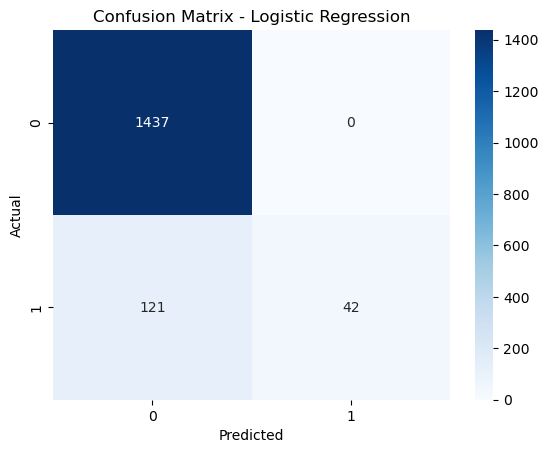

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [32]:
import pandas as pd

report_dict = classification_report(y_test, y_pred_lr, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv("lr_results.csv", index=True)

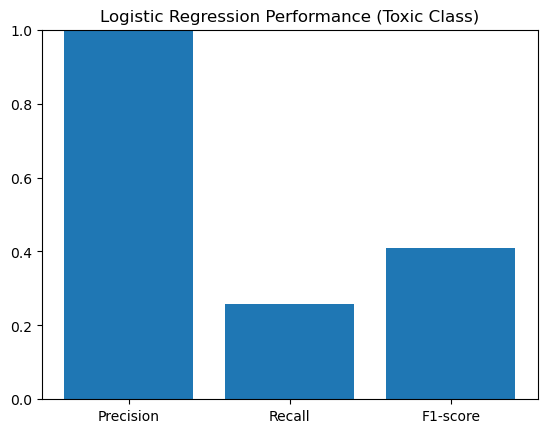

In [48]:
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)

lr_precision = report_lr['1']['precision']
lr_recall = report_lr['1']['recall']
lr_f1 = report_lr['1']['f1-score']

labels = ['Precision', 'Recall', 'F1-score']
scores = [lr_precision, lr_recall, lr_f1]

plt.bar(labels, scores)
plt.title("Logistic Regression Performance (Toxic Class)")
plt.ylim(0, 1)
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression

lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

lr_balanced.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [40]:
y_pred_bal = lr_balanced.predict(X_test_tfidf)

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1437
           1       0.72      0.71      0.72       163

    accuracy                           0.94      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.94      0.94      0.94      1600



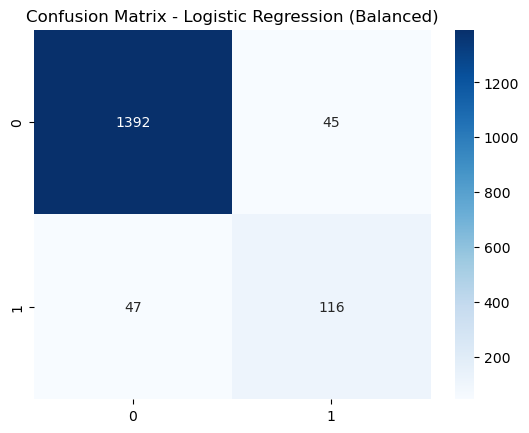

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_bal)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Balanced)")
plt.show()

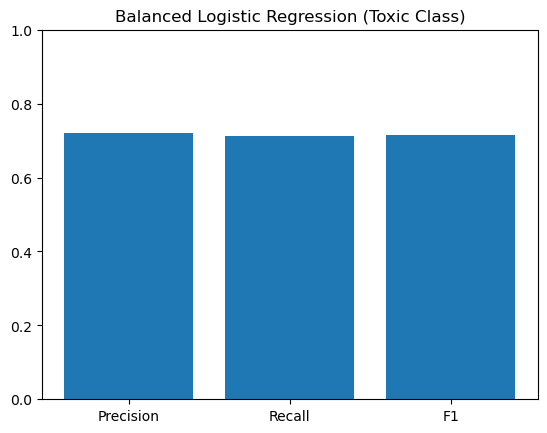

In [46]:
report = classification_report(y_test, y_pred_bal, output_dict=True)

precision = report['1']['precision']
recall = report['1']['recall']
f1 = report['1']['f1-score']

labels = ['Precision', 'Recall', 'F1']
scores = [precision, recall, f1]

plt.bar(labels, scores)
plt.title("Balanced Logistic Regression (Toxic Class)")
plt.ylim(0,1)
plt.show()

In [50]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression"
    ],
    "Toxic Precision": [
        report_lr['1']['precision'],
        report['1']['precision']
    ],
    "Toxic Recall": [
        report_lr['1']['recall'],
        report['1']['recall']
    ],
    "Toxic F1-score": [
        report_lr['1']['f1-score'],
        report['1']['f1-score']
    ],
    "Accuracy": [
        report_lr['accuracy'],
        report['accuracy']
    ]
})

results

,Model,Toxic Precision,Toxic Recall,Toxic F1-score,Accuracy
0,Logistic Regression,1.000000,0.257669,0.409756,0.924375
1,Balanced Logistic Regression,0.720497,0.711656,0.716049,0.942500


In [52]:
results.to_csv("model_comparison_results.csv", index=False)

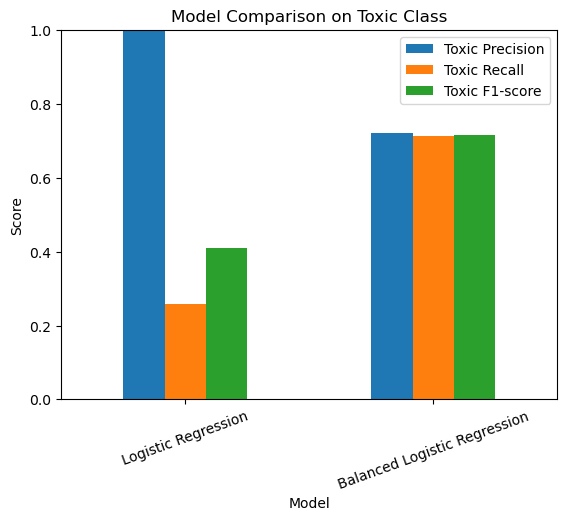

In [54]:
results.set_index("Model")[["Toxic Precision", "Toxic Recall", "Toxic F1-score"]].plot(kind="bar")
plt.title("Model Comparison on Toxic Class")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

### BERT

In [57]:
!pip install transformers torch

In [71]:
from transformers import pipeline

toxicity_classifier = pipeline(
    "text-classification",
    model="unitary/unbiased-toxic-roberta",
    truncation=True
)

config.json: 0.00B [00:00, ?B/s]

C:\Users\Lenovo\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Lenovo\.cache\huggingface\hub\models--unitary--unbiased-toxic-roberta. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

In [75]:
toxicity_classifier([
    "You are a great person, thank you.",
    "You are disgusting and stupid."
])

[{'label': 'toxicity', 'score': 0.0004022203793283552},
 {'label': 'toxicity', 'score': 0.9972667694091797}]

In [77]:
test_sample = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test.reset_index(drop=True)
}).sample(300, random_state=42)

bert_texts = test_sample["text"].tolist()
bert_labels = test_sample["label"].tolist()

In [79]:
bert_predictions = toxicity_classifier(
    bert_texts,
    batch_size=16,
    truncation=True,
    max_length=512
)

In [81]:
bert_pred_labels = []

for pred in bert_predictions:
    if pred["score"] >= 0.5:
        bert_pred_labels.append(1)
    else:
        bert_pred_labels.append(0)

In [83]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(bert_labels, bert_pred_labels))

              precision    recall  f1-score   support

           0       0.98      0.93      0.96       265
           1       0.62      0.89      0.73        35

    accuracy                           0.92       300
   macro avg       0.80      0.91      0.84       300
weighted avg       0.94      0.92      0.93       300



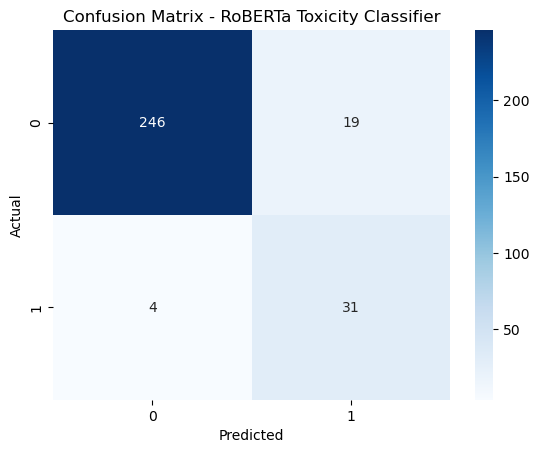

In [85]:
cm_bert = confusion_matrix(bert_labels, bert_pred_labels)

sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - RoBERTa Toxicity Classifier")
plt.show()

In [87]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "BERT (RoBERTa)"
    ],
    "Precision": [
        report_lr['1']['precision'],
        report['1']['precision'],
        0.62
    ],
    "Recall": [
        report_lr['1']['recall'],
        report['1']['recall'],
        0.89
    ],
    "F1-score": [
        report_lr['1']['f1-score'],
        report['1']['f1-score'],
        0.73
    ]
})

results

,Model,Precision,Recall,F1-score
0,Logistic Regression,1.000000,0.257669,0.409756
1,Balanced Logistic Regression,0.720497,0.711656,0.716049
2,BERT (RoBERTa),0.620000,0.890000,0.730000


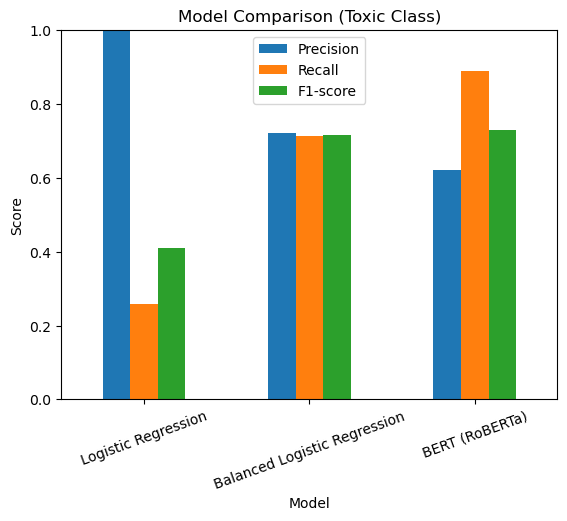

In [89]:
results.set_index("Model").plot(kind="bar")
plt.title("Model Comparison (Toxic Class)")
plt.ylim(0,1)
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [91]:
bert_report = classification_report(bert_labels, bert_pred_labels, output_dict=True)
pd.DataFrame(bert_report).transpose().to_csv("bert_results.csv")

In [101]:
test_comments = [
    "Thank you for your help, I really appreciate it.",
    "You are stupid and disgusting.",
    "I disagree with your opinion, but I respect it.",
    "Shut up, nobody likes you.",
    "This article is badly written.",
    "All Arsenal fans are weasel"
]

test_predictions = toxicity_classifier(
    test_comments,
    truncation=True,
    max_length=512
)

for comment, pred in zip(test_comments, test_predictions):
    score = pred["score"]
    label = "Toxic" if score >= 0.5 else "Non-toxic"
    print(f"Comment: {comment}")
    print(f"Prediction: {label} | Toxicity score: {score:.3f}")
    print("-" * 50)

Comment: Thank you for your help, I really appreciate it.
Prediction: Non-toxic | Toxicity score: 0.000
--------------------------------------------------
Comment: You are stupid and disgusting.
Prediction: Toxic | Toxicity score: 0.997
--------------------------------------------------
Comment: I disagree with your opinion, but I respect it.
Prediction: Non-toxic | Toxicity score: 0.000
--------------------------------------------------
Comment: Shut up, nobody likes you.
Prediction: Toxic | Toxicity score: 0.988
--------------------------------------------------
Comment: This article is badly written.
Prediction: Non-toxic | Toxicity score: 0.024
--------------------------------------------------
Comment: All Arsenal fans are weasel
Prediction: Toxic | Toxicity score: 0.831
--------------------------------------------------
